In [2]:
import np_rasp as rsp
import matplotlib.pyplot as plt
import string

In [67]:
help(rsp.select)

Help on function select in module np_rasp.core:

select(k, q, pred, causal=True)



In [ ]:
ppslct

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(38, 38))

In [70]:
row_sums = ppslct.sum(axis=1)
ppslct = ppslct / row_sums[:, np.newaxis]

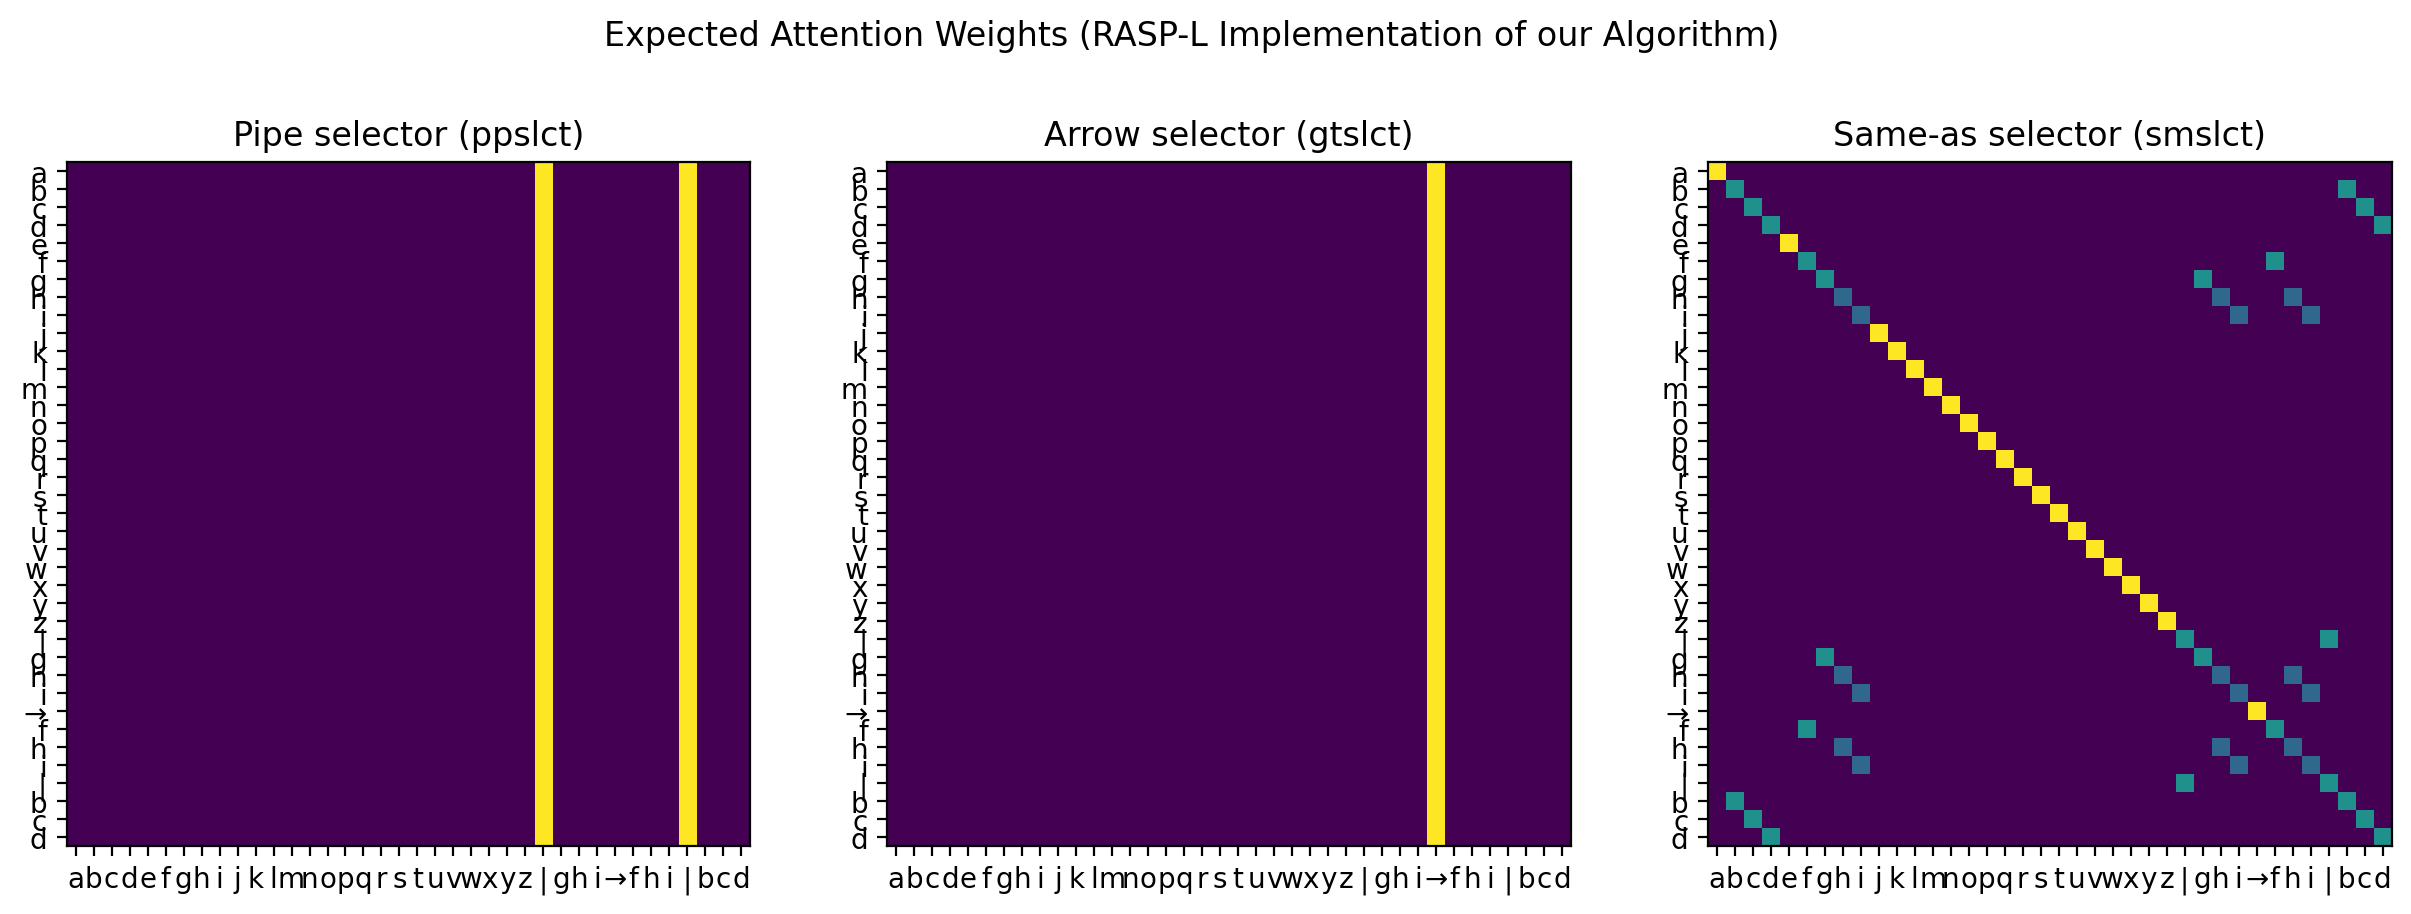

In [78]:
# Input string
s = string.ascii_lowercase + "|ghi→fhi|bcd"

# Convert chars to ascii ints
def tn(txt):
    return [ord(t) for t in txt]

## One layer
# Build selectors (QK circuits). These are probably general to all tasks
# and normalize each row to sum to 1
ppslct = rsp.select(k=tn(s), q=tn('|')*len(s), pred=rsp.equals, causal=False)
row_sums = ppslct.sum(axis=1)
ppslct = ppslct / row_sums[:, np.newaxis]

gtslct = rsp.select(k=tn(s), q=tn('→')*len(s), pred=rsp.equals, causal=False)
row_sums = gtslct.sum(axis=1)
gtslct = gtslct / row_sums[:, np.newaxis]

smslct = rsp.select(k=tn(s), q=tn(s),          pred=rsp.equals, causal=False) 
row_sums = smslct.sum(axis=1)
smslct = smslct / row_sums[:, np.newaxis]

# Find the index of the first character after each separator
x1_ind = rsp.aggr(ppslct, v=rsp.indices(s)+1, reduction='min')
x2_ind = rsp.aggr(gtslct, v=rsp.indices(s)+1, reduction='min')
qy_ind = rsp.aggr(ppslct, v=rsp.indices(s)+1, reduction='max')

# Get first occurrence of each element of string
# Example output for s = "abcdefghij|ghi>fhi|bcd"
# [ 0  1  2  3  4  5  6  7  8  9 10  6  7  8 14  5  7  8 10  1  2  3]
fstind = rsp.aggr(smslct, v=rsp.indices(s),   reduction='min')

## Next layer
# Locates x1, x2, and qy in alphabet
x1slct = rsp.select(k=rsp.indices(fstind), q=x1_ind, pred=rsp.equals, causal=False)
x2slct = rsp.select(k=rsp.indices(fstind), q=x2_ind, pred=rsp.equals, causal=False)
qyslct = rsp.select(k=rsp.indices(fstind), q=qy_ind, pred=rsp.equals, causal=False)

# To route qyind to next level
id     = rsp.select(k=rsp.indices(s), q=rsp.indices(s), pred=rsp.equals, causal=True)

x1_fst = rsp.aggr(x1slct, v=fstind, reduction='mean')
x2_fst = rsp.aggr(x2slct, v=fstind, reduction='mean')
qy_fst = rsp.aggr(qyslct, v=fstind, reduction='mean')
qy_ind

# Compute transformation of first element of query
# Corresponds to MLP operation
out_ind = x2_fst-x1_fst + qy_fst

## Next layer
# Note that the comparison is not exact because Rasp does not yet support decoder and cross-att
# Build component attention matrices id, o_slct, cpslct and combine using logical operations
id     = rsp.select(k=rsp.indices(s), q=rsp.indices(s), pred=rsp.equals, causal=True)
o_slct = rsp.select(k=rsp.indices(s), q=out_ind,        pred=rsp.equals, causal=True)
cpslct = rsp.select(k=rsp.indices(s), q=qy_ind,         pred=rsp.gt,     causal=True)

# Compare to last layer of decoder
o_slct = (o_slct | cpslct ) & id

# Non-zero elements of out1 correspond to 
out = rsp.aggr(o_slct, v=tn(s), default=0, reduction='mean')

fig, axs = plt.subplots(1, 3, figsize = (15, 5))
axs[0].imshow(ppslct)
axs[0].set_title("Pipe selector (ppslct)")
axs[1].imshow(gtslct)
axs[1].set_title("Arrow selector (gtslct)")
axs[2].imshow(smslct)
axs[2].set_title("Same-as selector (smslct)")

for ax in axs:
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(s)
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels(s)

fig.suptitle("Expected Attention Weights (RASP-L Implementation of our Algorithm)")
plt.show()

### MLC weights

In [ ]:
import sys 
import string

import analysis_utils as au
from intervenor import TransformerIntervenor
sys.path.append("../")
from checkpoint import CheckPoint
from datasets import LetterStringDataLoader

BATCH_SIZE = 10
%config InlineBackend.figure_format = 'retina'

In [19]:
# load checkpoints:
alph_perm200 = CheckPoint.from_pt("../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm200_nep20.pt")

# load models and dataset:
model_best = alph_perm200.load_model(verbose=False)
dataloader = LetterStringDataLoader(
    mode="test", 
    data_dir="../data/letter-string-analogies/perturbation_dataset", 
    batch_size=BATCH_SIZE, 
    batching_method="random",
    shuffle=False
)
# and batch predecessor (b c d -> a c d)
dataloader.dataset.set_filter("transformation_alphabet", [" | ".join(["pred", " ".join(list(string.ascii_lowercase))])])
batch_pred = next(iter(dataloader))

print("Batch pred")
print(" ".join(au.format_context_labels(batch_pred, idx=0)))

Batch pred
a b c d e f g h i j k l m n o p q r s t u v w x y z | g h i → f h i | b c d


In [20]:
inter = TransformerIntervenor(model_best)
inter.run_and_save(batch_pred)

In [57]:
import seaborn as sns

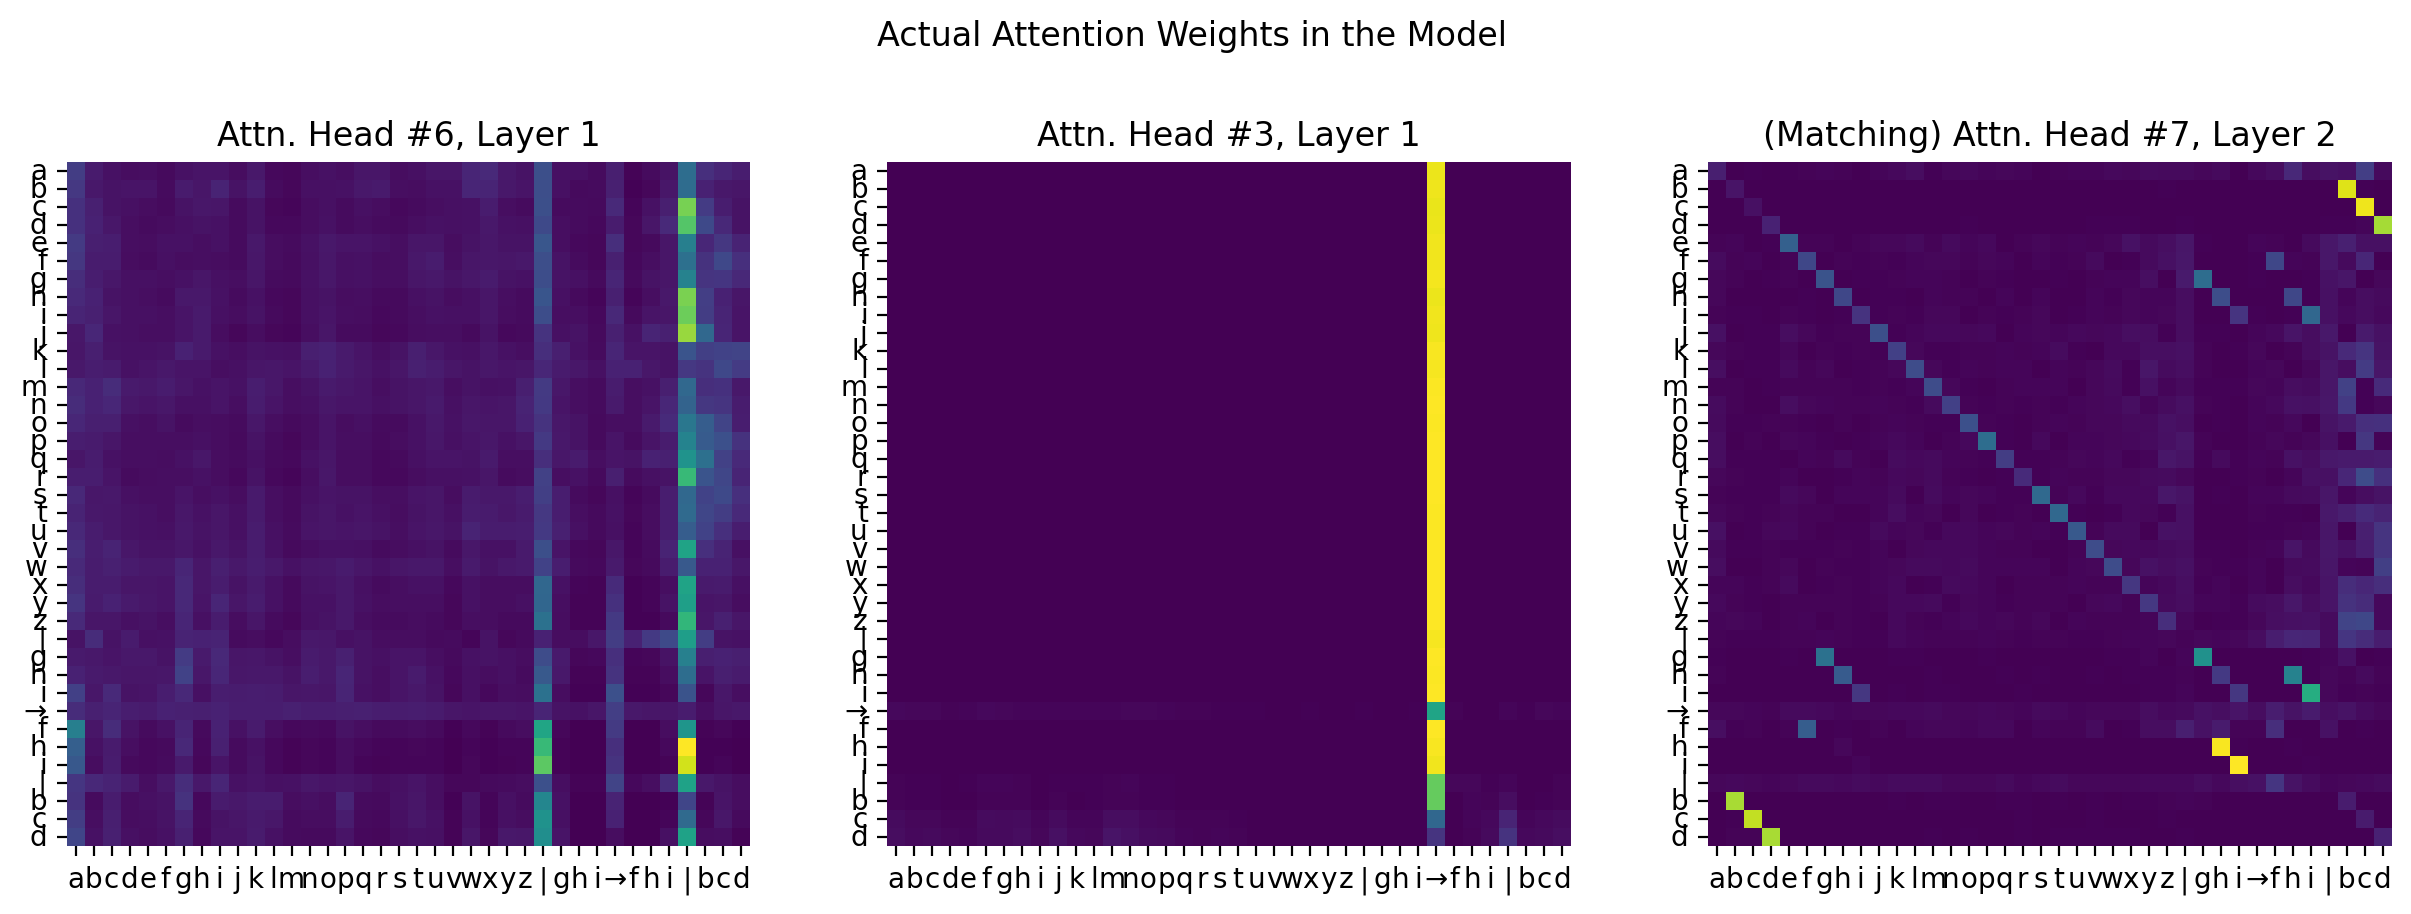

In [77]:
fig, ax = plt.subplots(1, 3, figsize = (15, 5))

LAYER_INDEX = 0
HEAD_INDEX = 5
ax[0].set_title(f"Attn. Head #{HEAD_INDEX+1}, Layer {LAYER_INDEX+1}")
sns.heatmap(
    inter.stored_activations["default"].encoder["attn"][f"layer_{LAYER_INDEX}"][0,HEAD_INDEX,:-1,:-1], 
    xticklabels=s,
    yticklabels=s,
    ax=ax[0],
    cbar=False,
    cmap="viridis",
    square=True)
ax[0].tick_params(axis='x', labelrotation=0)

LAYER_INDEX = 0
HEAD_INDEX = 2
ax[1].set_title(f"Attn. Head #{HEAD_INDEX+1}, Layer {LAYER_INDEX+1}")
sns.heatmap(
    inter.stored_activations["default"].encoder["attn"][f"layer_{LAYER_INDEX}"][0,HEAD_INDEX,:-1,:-1], 
    xticklabels=s,
    yticklabels=s,
    ax=ax[1],
    cbar=False,
    cmap="viridis",
    square=True)
ax[1].tick_params(axis='x', labelrotation=0)

LAYER_INDEX = 1
HEAD_INDEX = 6
ax[2].set_title(f"(Matching) Attn. Head #{HEAD_INDEX+1}, Layer {LAYER_INDEX+1}")
sns.heatmap(
    inter.stored_activations["default"].encoder["attn"][f"layer_{LAYER_INDEX}"][0,HEAD_INDEX,:-1,:-1], 
    xticklabels=s,
    yticklabels=s,
    ax=ax[2],
    cbar=False,
    cmap="viridis",
    square=True)
ax[2].tick_params(axis='x', labelrotation=0)

plt.suptitle("Actual Attention Weights in the Model")
plt.show()